# XGBoost

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import FunctionTransformer

from heart_failure.features import get_prep_pipeline
from heart_failure.dataset import split_data
from heart_failure.modeling.models import build_xgboost_pipeline
from heart_failure.modeling.train import optuna_search, xgboost_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, F_BETA_THRESHOLD, MIN_RECALL
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold
)
from heart_failure.modeling.cv import cross_val_score_sw
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

In [2]:
MODEL_NAME = "xgboost"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

In [ ]:
fe_pipeline = get_prep_pipeline(n_bins=8)
cv_params = {}
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=80,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    n_jobs=8,
)

In [5]:
print_best_params(study)

Best parameters: {'model__n_estimators': 641, 'model__learning_rate': 0.003757579919997927, 'model__gamma': 0.965836046402327, 'model__max_depth': 2, 'model__reg_lambda': 0.0007274743272170801, 'model__reg_alpha': 0.002224126798131082, 'model__subsample': 0.9703212301277523, 'use_binner': True}
Best score: 0.81767


In [6]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
57,"{'model__n_estimators': 641, 'model__learning_...",0.054638,0.817666,0.809524,0.839506,0.790698,0.906667,0.741935,1
71,"{'model__n_estimators': 734, 'model__learning_...",0.051696,0.817521,0.772727,0.829268,0.839506,0.896104,0.750000,2
75,"{'model__n_estimators': 724, 'model__learning_...",0.058238,0.816199,0.755556,0.839506,0.829268,0.906667,0.750000,3
73,"{'model__n_estimators': 602, 'model__learning_...",0.052243,0.815327,0.800000,0.829268,0.790698,0.906667,0.750000,4
65,"{'model__n_estimators': 594, 'model__learning_...",0.057786,0.814810,0.766667,0.839506,0.819277,0.906667,0.741935,5


#### Feature importance

In [7]:
tree = model.named_steps["model"]
pd.Series(tree.feature_importances_, index=fe_pipeline.transform(X).columns).sort_values(ascending=False)

target_encoder__ST_Slope          0.417128
binary_encoder__ExerciseAngina    0.166702
target_encoder__ChestPainType     0.085600
binary_encoder__Sex               0.066733
binary_encoder__FastingBS         0.065137
remainder__Oldpeak                0.058431
binner__Age                       0.045144
binner__MaxHR                     0.044277
binner__Cholesterol               0.025988
remainder__RestingBP              0.024861
target_encoder__RestingECG        0.000000
dtype: float32

### Threshold searching

In [8]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float32(0.33702144)

## Metrics

In [9]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.859788
recall       0.912921
fpr          0.183391
pr_auc       0.945220
dtype: float64

In [10]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.770492
recall       0.959184
fpr          0.358974
pr_auc       0.919994
dtype: float64

The model is better than all previous ones, but the FPR is still too high. I'd like to see it reduced to at least 0.25.

### Confusion Matrix

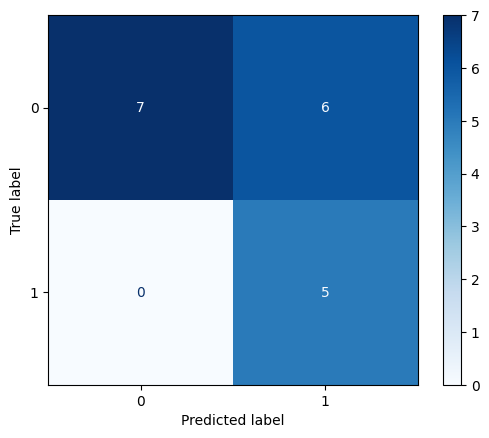

In [21]:
female = X_val[SEX] == "F"
ConfusionMatrixDisplay.from_predictions(y_val[female], y_val_pred[female], cmap="Blues")
plt.show()

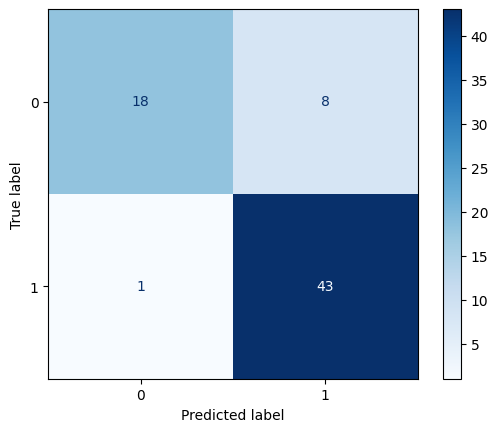

In [22]:
ConfusionMatrixDisplay.from_predictions(y_val[~female], y_val_pred[~female], cmap="Blues")
plt.show()

When using sample_weight, FP for women does not change at all - it is always 6.

### PR-curve

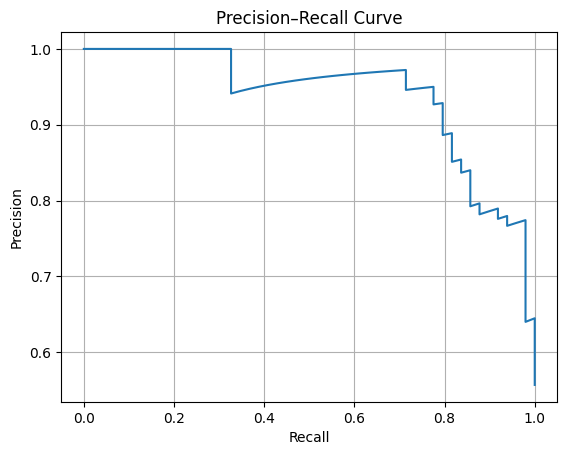

In [23]:
plot_pr_curve(y_val, y_val_proba)

### Test metrics

In [24]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.775194
recall       0.980392
fpr          0.353659
pr_auc       0.903664
dtype: float64

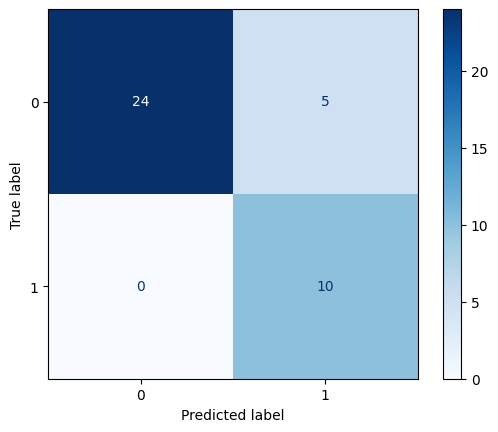

In [25]:
female = X_test[SEX] == "F"
ConfusionMatrixDisplay.from_predictions(y_test[female], y_test_pred[female], cmap="Blues")
plt.show()

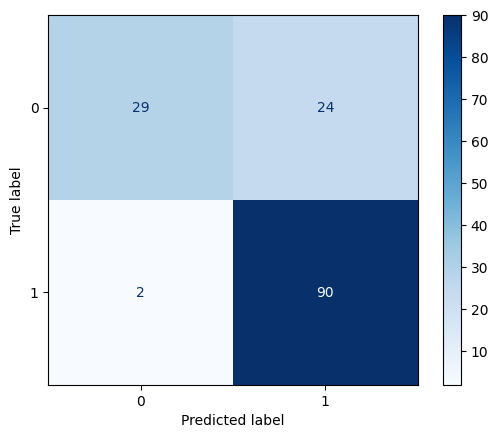

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test[~female], y_test_pred[~female], cmap="Blues")
plt.show()

Next, I want to consider the following questions:
- Why is the score always worse on split_1 than on the other splits?
- How can the models be improved? What features should be added?
- Comparison of models and their predictions. Do they have the same FN?
- Which model is currently the best?

In [ ]:
cv_results = optuna_cv_results_to_df(study)

with mlflow.start_run(run_name=MODEL_NAME) as run:
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(best_cv_result, artifact_file="best_cv_result.json")
    for i in range(CV_SPLITS):
        mlflow.log_metric(f"cv_split_{i}_score", best_cv_result[f"split_test_{i}"])

    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", "all")
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)
    mlflow.log_param("optuna_scoring", "prec_by_fixed_recall")
    mlflow.log_dict(cv_params, artifact_file="cv_params.json")

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")

## Version with raw features

In [57]:
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].astype("category")

In [58]:
y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

In [ ]:
fe_pipeline = FunctionTransformer(lambda x: x, validate=False)
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    cat_features=True,
    cv_scorer=cross_val_score_sw,
    cv_params=cv_params,
)

In [60]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
27,"{'model__n_estimators': 315, 'model__learning_...",0.038321,0.821458,0.764045,0.809524,0.819277,0.883117,0.831325,1
49,"{'model__n_estimators': 379, 'model__learning_...",0.038699,0.815641,0.764045,0.819277,0.800000,0.883117,0.811765,2
11,"{'model__n_estimators': 421, 'model__learning_...",0.026314,0.814682,0.781609,0.800000,0.819277,0.860759,0.811765,3
47,"{'model__n_estimators': 362, 'model__learning_...",0.037304,0.811678,0.755556,0.819277,0.800000,0.871795,0.811765,4
21,"{'model__n_estimators': 589, 'model__learning_...",0.049600,0.811031,0.739130,0.809524,0.800000,0.894737,0.811765,5


In [61]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float32(0.19955653)

### Metrics

In [62]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.912329
recall       0.935393
fpr          0.110727
pr_auc       0.977810
dtype: float64

In [63]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.770492
recall       0.959184
fpr          0.358974
pr_auc       0.926159
dtype: float64

In [64]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.776923
recall       0.990196
fpr          0.353659
pr_auc       0.922364
dtype: float64

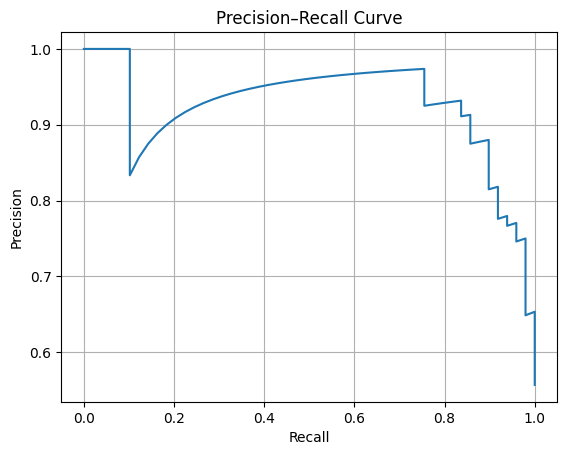

In [65]:
plot_pr_curve(y_val, y_val_proba)

Metrics are slightly worse on validation set and folds. Accordingly, it is better to use XGBoost with transformed features.